In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv('sales.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [99]:
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


In [100]:
# Train test split
train = df.iloc[:-14]       # First 351 samples in the training set
test = df.iloc[-14:]        # Last 14 samples in the test set

# Horizon. How many steps ahead we need to predict. This is equal to the length of the test set. Every forecast method needs to produce exactly h values
h = len(test)

# Simple Moving Average (SMA)

In [101]:
k_sma = 7

In [102]:
# train['sales'].shift(1) — shifts the entire series forward by one step. After shifting, the value at position t is what was originally at position t-1. This is the data leakage prevention step.
# .rolling(window=k_sma) — creates a rolling window object of size 7. This does not compute anything yet — it just defines the window configuration.
# .mean() — computes the mean within each window position. The first k-1 values (6 rows here) become NaN because there are not enough past values to fill the window.
sma = train['sales'].shift(1).rolling(window=k_sma).mean()

In [103]:
print(train.head(30))

            sales
date             
2022-01-01   1200
2022-01-02    980
2022-01-03   1100
2022-01-04    870
2022-01-05    760
2022-01-06   1450
2022-01-07   1600
2022-01-08   1150
2022-01-09   1020
2022-01-10   1080
2022-01-11    930
2022-01-12    850
2022-01-13   1520
2022-01-14   1650
2022-01-15   1180
2022-01-16   1050
2022-01-17   1120
2022-01-18    960
2022-01-19    880
2022-01-20   1580
2022-01-21   1700
2022-01-22   1220
2022-01-23   1090
2022-01-24   1160
2022-01-25   1000
2022-01-26    920
2022-01-27   1620
2022-01-28   1750
2022-01-29   1260
2022-01-30   1130


In [104]:
sma.head(30)

date
2022-01-01            NaN
2022-01-02            NaN
2022-01-03            NaN
2022-01-04            NaN
2022-01-05            NaN
2022-01-06            NaN
2022-01-07            NaN
2022-01-08    1137.142857
2022-01-09    1130.000000
2022-01-10    1135.714286
2022-01-11    1132.857143
2022-01-12    1141.428571
2022-01-13    1154.285714
2022-01-14    1164.285714
2022-01-15    1171.428571
2022-01-16    1175.714286
2022-01-17    1180.000000
2022-01-18    1185.714286
2022-01-19    1190.000000
2022-01-20    1194.285714
2022-01-21    1202.857143
2022-01-22    1210.000000
2022-01-23    1215.714286
2022-01-24    1221.428571
2022-01-25    1227.142857
2022-01-26    1232.857143
2022-01-27    1238.571429
2022-01-28    1244.285714
2022-01-29    1251.428571
2022-01-30    1257.142857
Name: sales, dtype: float64

In [105]:
# SMA forecast — mean of last k observations from training set

# Selects the last 7 values from the training set and calculates the mean. this is the final window of training data
sma_forecast_val = train['sales'].iloc[-k_sma:].mean()
print(sma_forecast_val)

3062.8571428571427


In [106]:
fc_sma = pd.Series(
    np.repeat(sma_forecast_val, h),
    index=test.index
)

In [107]:
fc_sma

date
2022-12-18    3062.857143
2022-12-19    3062.857143
2022-12-20    3062.857143
2022-12-21    3062.857143
2022-12-22    3062.857143
2022-12-23    3062.857143
2022-12-24    3062.857143
2022-12-25    3062.857143
2022-12-26    3062.857143
2022-12-27    3062.857143
2022-12-28    3062.857143
2022-12-29    3062.857143
2022-12-30    3062.857143
2022-12-31    3062.857143
dtype: float64

# Weighted Moving Average (WMA)

In [108]:
k_wma = 7

# creates the array [1, 2, 3, 4, 5, 6, 7]. These are the raw weights before normalisation. The most recent observation gets weight 7, the oldest gets weight 1.
weights = np.arange(1, k_wma + 1)
print(weights)

[1 2 3 4 5 6 7]


In [109]:
# divides every element by the total sum (which is 28 for k=7). This normalises the weights so they sum to 1
weights = weights / weights.sum()             # normalise to sum to 1

In [110]:
weights

array([0.03571429, 0.07142857, 0.10714286, 0.14285714, 0.17857143,
       0.21428571, 0.25      ])

In [111]:
# Apply weighted rolling window

# train['sales'].iloc[-k_wma:].values --> the last 7 training values as a numpy array. The .values is required because np.dot works on arrays, not pandas Series.
# np.dot(..., weights) — dot product. This multiplies each of the 7 values by its corresponding weight and sums the results:
wma_forecast_val = np.dot(train['sales'].iloc[-k_wma:].values, weights)
wma_forecast_val

np.float64(3217.8571428571427)

In [116]:
fc_wma = pd.Series(np.repeat(wma_forecast_val, h), index=test.index)
fc_wma


# What this block does as a whole: Computes a weighted forecast where recent observations matter more than older ones. Compared to SMA, this typically produces a slightly different (usually slightly higher or lower) forecast that tracks recent momentum better.

date
2022-12-18    3217.857143
2022-12-19    3217.857143
2022-12-20    3217.857143
2022-12-21    3217.857143
2022-12-22    3217.857143
2022-12-23    3217.857143
2022-12-24    3217.857143
2022-12-25    3217.857143
2022-12-26    3217.857143
2022-12-27    3217.857143
2022-12-28    3217.857143
2022-12-29    3217.857143
2022-12-30    3217.857143
2022-12-31    3217.857143
dtype: float64

# Cumulative Moving Average (CMA)

In [117]:
# .expanding() — creates an expanding window object. Unlike .rolling() which has a fixed size, .expanding() always starts from the first observation and grows by one row each step.
# .mean() — computes the mean of all observations from the start-up to each point

cma = train['sales'].expanding().mean()       # window grows with each step
cma

date
2022-01-01    1200.000000
2022-01-02    1090.000000
2022-01-03    1093.333333
2022-01-04    1037.500000
2022-01-05     982.000000
                 ...     
2022-12-13    2019.942363
2022-12-14    2021.925287
2022-12-15    2023.638968
2022-12-16    2028.428571
2022-12-17    2033.589744
Name: sales, Length: 351, dtype: float64

In [114]:
def mae(forecast, actual):
    return np.mean(np.abs(forecast.values - actual.values))

print(f"SMA (k={k_sma}) MAE : {mae(fc_sma, test['sales']):.2f}")
print(f"WMA (k={k_wma}) MAE : {mae(fc_wma, test['sales']):.2f}")

SMA (k=7) MAE : 417.14
WMA (k=7) MAE : 436.53


# Plot

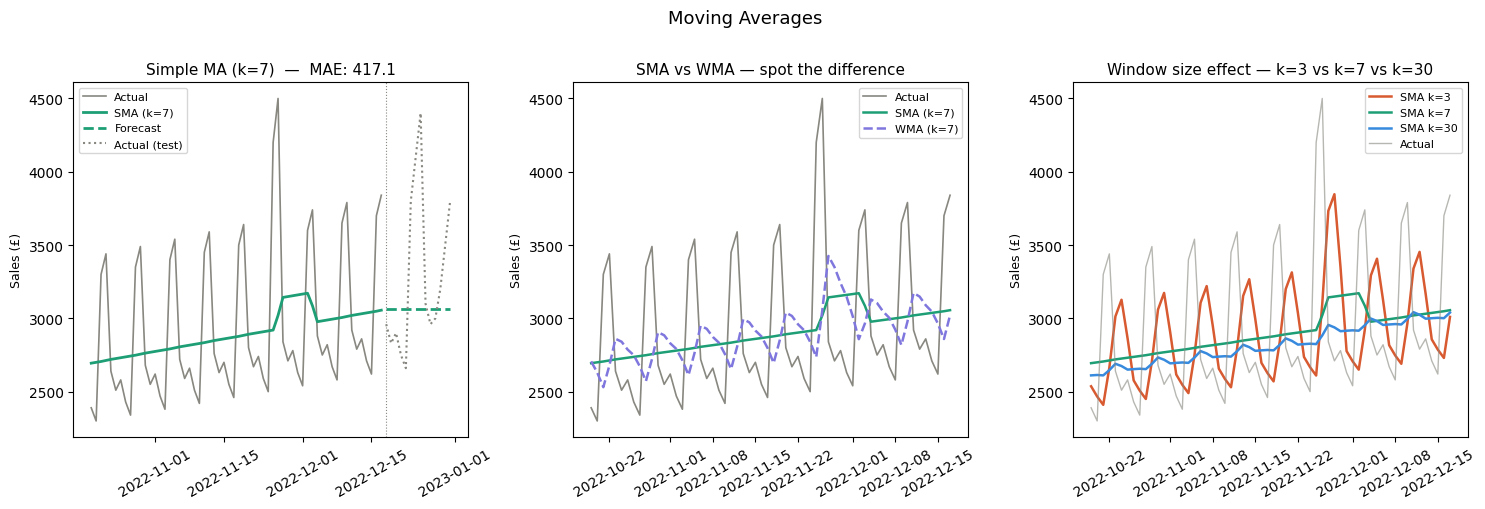

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

train_plot = train['sales'].iloc[-60:]

# Panel 1 — SMA
axes[0].plot(train_plot.index, train_plot.values,
             color='#888780', linewidth=1.2, label='Actual')
axes[0].plot(sma.iloc[-60:].index, sma.iloc[-60:].values,
             color='#1D9E75', linewidth=2, label=f'SMA (k={k_sma})')
axes[0].plot(test.index, fc_sma.values,
             color='#1D9E75', linewidth=2, linestyle='--', label='Forecast')
axes[0].plot(test.index, test['sales'].values,
             color='#888780', linewidth=1.5, linestyle=':', label='Actual (test)')
axes[0].axvline(test.index[0], color='#888780', linewidth=0.8, linestyle=':')
axes[0].set_title(f'Simple MA (k={k_sma})  —  MAE: {mae(fc_sma, test["sales"]):.1f}',
                  fontsize=11)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

# Panel 2 — WMA vs SMA comparison
axes[1].plot(train_plot.index, train_plot.values,
             color='#888780', linewidth=1.2, label='Actual')
axes[1].plot(sma.iloc[-60:].index, sma.iloc[-60:].values,
             color='#1D9E75', linewidth=1.8, label=f'SMA (k={k_sma})')
axes[1].plot(train['sales'].shift(1).rolling(k_wma).apply(
                 lambda x: np.dot(x, weights)).iloc[-60:],
             color='#7F77DD', linewidth=1.8, linestyle='--',
             label=f'WMA (k={k_wma})')
axes[1].set_title('SMA vs WMA — spot the difference', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=30)

# Panel 3 — effect of window size
colors = ['#D85A30', '#1D9E75', '#378ADD']
for k, color in zip([3, 7, 30], colors):
    s = train['sales'].shift(1).rolling(k).mean()
    axes[2].plot(s.iloc[-60:].index, s.iloc[-60:].values,
                 color=color, linewidth=1.8, label=f'SMA k={k}')
axes[2].plot(train_plot.index, train_plot.values,
             color='#888780', linewidth=1.0, alpha=0.6, label='Actual')
axes[2].set_title('Window size effect — k=3 vs k=7 vs k=30', fontsize=11)
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.set_ylabel('Sales (£)', fontsize=9)

plt.suptitle('Moving Averages', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()